# Spectrogram and ERD grid plots

This notebook is used for creating a grid of spectrograms and ERD plots for all channels

Author: Magnus Evensen, Malte Færgemann Lau $\\$
Project: Bachelor's Project - EEG Social Interaction

In [19]:
import h5py
import numpy as np
import mne
import os
import pandas as pd
import glob
import gc
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib as mpl

# mpl setup
mpl.rcParams['image.cmap'] = 'ocean'
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set2(np.linspace(0, 1, 8)))
# plt.rcParams['axes.prop_cycle'] = plt.cycler(color = [(225/255,102/255,102/255), (82/255,158/255,205/255),  (194/255,226/255,170/255), (225/255,178/255,102/255), (178/255,102/255,225/255),(225/255,225/255,102/255),(102/255,102/255,225/255)])
mpl.rcParams['font.family'] = 'Helvetica Neue'
mpl.rcParams['figure.figsize'] = (6, 4)
mpl.rcParams['lines.linewidth'] = 1
mpl.rcParams['figure.dpi'] = 100
%config InlineBackend.figure_format = 'retina'
%matplotlib widget
dtu_colors = {'dtured' : (0.6,0,0), 'navyblue' : (0.0118,0.0588,0.3098), 'red' : (0.9098,0.2471,0.2824), 'blue': (0.1843,0.2431,0.9176), 'green' : (0,0.5333,0.2078), 'orange' : (0.9882,0.4627,0.2039), 'purple' : (0.4745,0.1373,0.5569), 'brightgreen' : (0.1216,0.8157,0.5098), 'yellow' : (0.9647,0.8157,0.3019), 'pink' : (0.9686,0.7333,0.6941), 'grey' : (0.8549,0.8549,0.8549), 'red' : (0.9098,0.2471,0.2824)}

In [5]:
path = os.path.abspath('../FG_Data/FG_overview_df_v2.pkl')
overview = pd.read_pickle(path)
overview

,Subject_id,Exp_id,Friend_status,EEG_device,Force_device,Force_port,Age,Gender,Class_friends,Class_close_friends,Friends,Close_friends,Triad_id,Participant,tFriends,tClose_friends,All_friends,tClass,rClass
0,1049,301A,Yes,1,1,1,22.239562,F,3,6,9,14,301,P1,12,20,32,9,0.666667
1,1029,301B,No,2,3,2,24.331280,M,3,1,8,5,301,P2,11,6,17,4,0.250000
2,1028,301C,Yes,3,4,3,21.670089,M,8,4,9,4,301,P3,17,8,25,12,0.333333
3,1064,302A,Yes,1,1,1,22.009582,M,14,8,11,5,302,P1,25,13,38,22,0.363636
4,1024,302B,Yes,2,3,2,21.355236,M,5,7,6,10,302,P2,11,17,28,12,0.583333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,6069,330B,No,2,3,2,19.373032,F,14,3,17,17,330,P2,31,20,51,17,0.176471
88,6048,330C,Yes,3,4,3,19.841205,M,13,11,25,26,330,P3,38,37,75,24,0.458333
89,6015,331A,Yes,1,1,1,20.052019,M,9,4,14,13,331,P1,23,17,40,13,0.307692
90,6183,331B,Yes,2,3,2,18.863792,M,22,6,25,12,331,P2,47,18,65,28,0.214286


In [6]:
# Create df for plots
folder_path = os.path.abspath('../FG_Data/PreprocessedEEGData')

# Use glob to find all FIF files in the folder
epoch_files = glob.glob(os.path.join(folder_path, '*-epo.fif'))
epochs_list = []

for f in epoch_files: # Load each FIF file into a list of epoch objects
    
    basename = os.path.basename(f) # Extract participant ID from filename
    
    Exp_id = basename.split('_')[0] # Get Exp id
    
    gender = overview.loc[overview['Exp_id'] == Exp_id, 'Gender'].iloc[0]
    
    epochs = mne.read_epochs(f, preload=False, verbose=False)
    epochs_list.append({ # Construct list of corresponding exp id, gender and epochs
        'Exp_id': Exp_id,
        'Gender': gender,
        'Epochs': epochs
    })
epochs_df = pd.DataFrame(epochs_list)
sfreq = int(epochs_df['Epochs'][0].info['sfreq'])
n_epochs, n_channels, n_timepoints = epochs_df['Epochs'][0].get_data().shape
epochs_df

Loading data for 298 events and 3000 original time points ...


,Exp_id,Gender,Epochs
0,326A,M,"<EpochsFIF | 298 events (all good), -0.5 – 5...."
1,311A,M,"<EpochsFIF | 300 events (all good), -0.5 – 5...."
2,318B,F,"<EpochsFIF | 298 events (all good), -0.5 – 5...."
3,315A,F,"<EpochsFIF | 295 events (all good), -0.5 – 5...."
4,322A,F,"<EpochsFIF | 300 events (all good), -0.5 – 5...."
...,...,...,...
87,303C,M,"<EpochsFIF | 299 events (all good), -0.5 – 5...."
88,309A,F,"<EpochsFIF | 300 events (all good), -0.5 – 5...."
89,308B,F,"<EpochsFIF | 299 events (all good), -0.5 – 5...."
90,305A,M,"<EpochsFIF | 296 events (all good), -0.5 – 5...."


In [7]:
def roof(x):
    return int(x) + 1 if x > int(x) else int(x)

In [157]:
def get_psds_for_channel(participants_data, channel, settings, window, band = [1,40], overlap = 0.75, mean = True):
    
    overlap = int(window * sfreq * overlap) # scale overlap to window size
    psd_dict = {}
    for setting in settings:
        all_psds = []
        for epochs in participants_data:
            # Pick channel 
            filtered_epochs = epochs.copy().load_data().pick([channel])
            filtered_epochs = filtered_epochs.filter(l_freq=band[0], h_freq=band[1], fir_design='firwin', n_jobs=10, verbose = False)
            filtered_epochs = filtered_epochs[setting]
            #filtered_epochs = filtered_epochs.apply_baseline(baseline=(-0.25,0))
            # Compute PSD
            psds = filtered_epochs.compute_psd(method='welch', window = 'hamming', average = None, 
                                               fmin=band[0], fmax=band[1], n_fft=int(sfreq*window*2/band[0]), 
                                               n_overlap=int(overlap*2/band[0]), n_jobs=10, verbose = False);
            if mean:
                #print(np.array(psds.get_data()).mean(axis = 1).shape)
                mean_psds = np.array(psds.get_data().mean(axis=0).mean(axis = 1)).flatten()
                # Standardize to baseline 
                baseline = mean_psds[int(len(mean_psds)/20):int(len(mean_psds)/10)].mean() 
                all_psds.append(mean_psds/baseline) # append the mean over epochs and frequencies to all psds
            else:
                psds_list = np.array(psds.get_data().mean(axis=0))
                #mean_psds = np.array(psds.get_data().mean(axis=0).mean(axis = 1)).flatten()
                #subset_means = psds_list[:, int(len(mean_psds)/20):int(len(mean_psds)/10)].mean(axis=1)
                #normalized_arr = psds_list / subset_means[:, np.newaxis]
                all_psds.append(psds_list)
            # Unload data from iteration to save memory space
            del filtered_epochs
            gc.collect()
            
        label = f'{setting}, {band} frequencies, channel {channel}'
        psd_dict[label] = np.reshape(all_psds, (len(all_psds), len(all_psds[0]))) if mean else np.reshape(all_psds, (len(all_psds[0][0]), len(all_psds[0][0][0])))
        
    return psd_dict

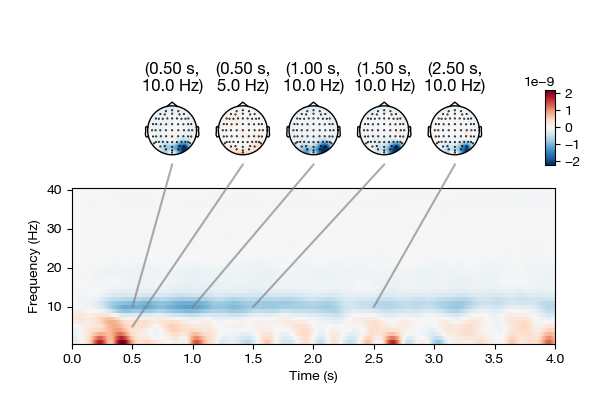

In [117]:
epochs = epochs_df['Epochs'][0]
setting = 'T1P'
channel = 'C3'
filtered_epochs = epochs.copy().load_data()
filtered_epochs = filtered_epochs[setting]

freqs = np.arange(1,41)
n_cycles = freqs / 2.0

#Compute TFR
power = mne.time_frequency.tfr_morlet(filtered_epochs, freqs=freqs, n_cycles=n_cycles, use_fft=True, return_itc=False, average=True, n_jobs=-1, verbose = False)
power.plot_joint(baseline=(-0.25, 0), mode="mean", tmin=0, tmax=4, timefreqs=[(0.5,10), (0.5, 5), (1, 10), (1.5,10), (2.5,10)], topomap_args=dict(contours=0));

In [ ]:
def plot_ERD(psds_dict, ax): 
    """ Takes a dict where each value should be of size (n_segments, n_channels), \\
    and returns frequency over time plots in a (n_items, 2) grid"""
    times = np.linspace(-0.5, 5.5, len(next(iter(psds_dict.values()))[0])) # Create time points equal to powers
    
    for data_label, powers in psds_dict.items():
        mean_line = np.mean(powers, axis = 0)
        std_line = np.std(powers, axis = 0)/np.sqrt(len(powers))
        ax.plot(times, mean_line, label = data_label)
        ax.fill_between(times, mean_line - std_line, mean_line + std_line, alpha=0.3)
    
    ax.axhline(y=1, color='black', linestyle='--', label='baseline', alpha = 0.3) # plot baseline
    ax.set_ylim(0.5,1.3)
    ax.set_xlim(-0.1,4)
    #ax.legend()
    #plt.show()

In [161]:
channel = 'C3'
psd = get_psds_for_channel(epochs_df['Epochs'][:1], channel = channel, settings = ['T1P'], window = 1, overlap = 0.9, mean = False)#['T1P, [1, 40] frequencies, channel C3']

In [151]:
len(psd[0,0,:,0])

79

In [168]:
def plot_diff_Spectrogram(dict, ax=0):
    # Optional: convert to dB
    for psds in dict.values():
        #psds_db = 10 * np.log10(psds)

        # Plot
        plt.figure(figsize=(10, 4))
        plt.imshow(psds, aspect='auto', origin='lower',
                extent=[0, psds.shape[1], freqs[0], freqs[-1]],
                cmap='viridis')
        plt.colorbar(label='Power (dB)')
        plt.xlabel('Time Index' if 'times' not in locals() else 'Time (s)')
        plt.ylabel('Frequency (Hz)')
        plt.title('Spectrogram')
        plt.tight_layout()
        plt.show()

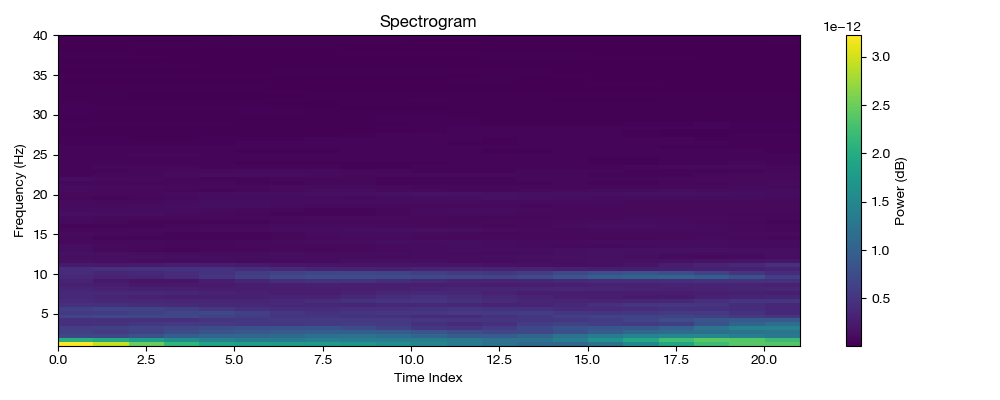

In [169]:
plot_diff_Spectrogram(psd)

In [103]:
ch_grid_dict = {                                       'Fp1':(2.7,0), 'Fpz':(4,0), 'Fp2':(5.3,0),
                                          'AF7':(1.3,1), 'AF3':(2.5,1), 'AFz':(4,1), 'AF4':(5.5,1), 'AF8':(6.7,1),
                'F7':(0,2),  'F5':(1,2),  'F3':(2,2),  'F1':(3,2),  'Fz':(4,2),  'F2':(5,2),  'F4':(6,2),  'F6':(7,2),  'F8':(8,2),
                'FT7':(0,3), 'FC5':(1,3), 'FC3':(2,3), 'FC1':(3,3), 'FCz':(4,3), 'FC2':(5,3), 'FC4':(6,3), 'FC6':(7,3), 'FT8':(8,3),
                'T7':(0,4),  'C5':(1,4),  'C3':(2,4),  'C1':(3,4),  'Cz':(4,4),  'C2':(5,4),  'C4':(6,4),  'C6':(7,4),  'T8':(8,4),
                'TP7':(0,5), 'CP5':(1,5), 'CP3':(2,5), 'CP1':(3,5), 'CPz':(4,5), 'CP2':(5,5), 'CP4':(6,5), 'CP6':(7,5), 'TP8':(8,5),
                'P7':(0,6),  'P5':(1,6),  'P3':(2,6),  'P1':(3,6),  'Pz':(4,6),  'P2':(5,6),  'P4':(6,6),  'P6':(7,6),  'P8':(8,6),
                'P9':(0,7),                                                                                             'P10':(8,7),
                                          'PO7':(1.3,7), 'PO3':(2.5,7), 'POz':(4,7), 'PO4':(5.5,7), 'PO8':(6.7,7),
                                                       'O1':(2.8,8),  'Oz':(4,8),  'O2':(5.2,8),
                                                                    'Iz':(4,9)
                
                }

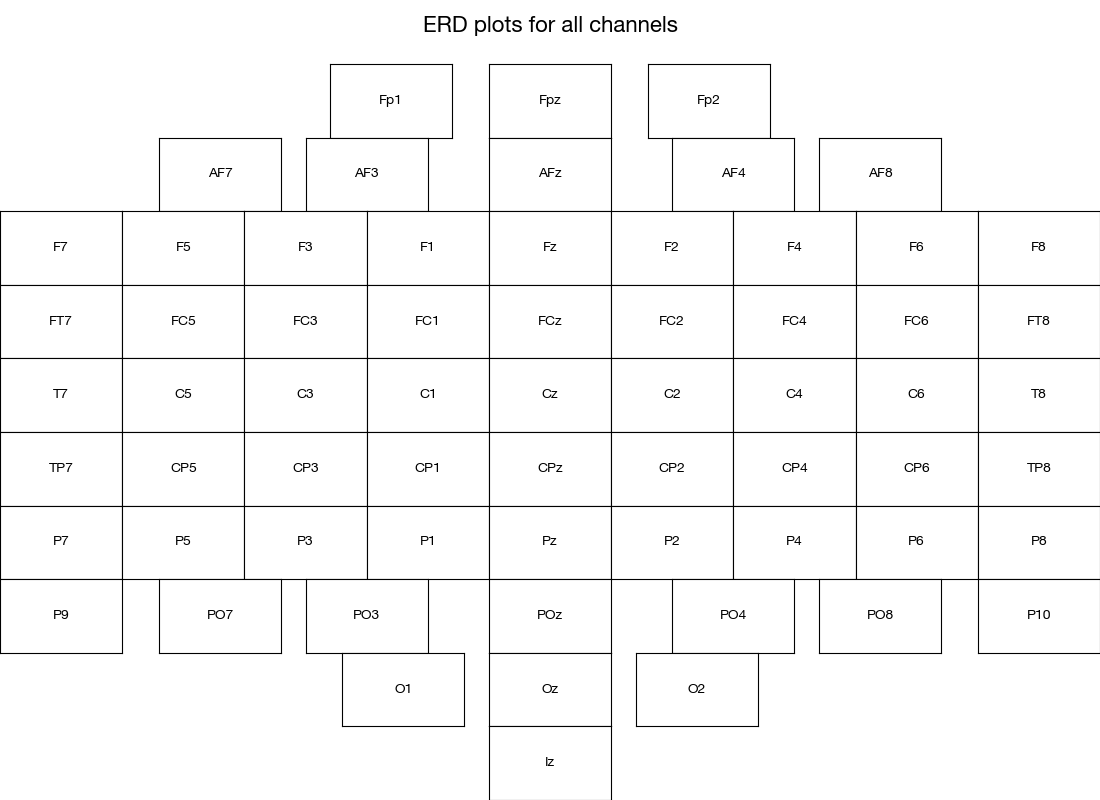

In [104]:
import matplotlib.pyplot as plt

# Define grid size based on your ch_grid_dict
n_cols = max(pos[0] for pos in ch_grid_dict.values()) + 1
n_rows = max(pos[1] for pos in ch_grid_dict.values()) + 1

fig = plt.figure(figsize=(11, 8))

for ch, (x, y) in ch_grid_dict.items():
    # Normalize positions to [0, 1] figure coordinates
    top_margin = 0.08  # 5% of figure height reserved
    ax_width = 1 / n_cols
    ax_height = (1 - top_margin) / n_rows

    left = x * ax_width
    bottom = 1 - top_margin - (y + 1) * ax_height  # shift all axes down

    ax = fig.add_axes([left, bottom, ax_width, ax_height])

    # Placeholder content — replace with your actual plot later
    ax.text(0.5, 0.5, ch, ha='center', va='center', fontsize=10)
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
plt.suptitle("ERD plots for all channels", fontsize=16)
plt.show()


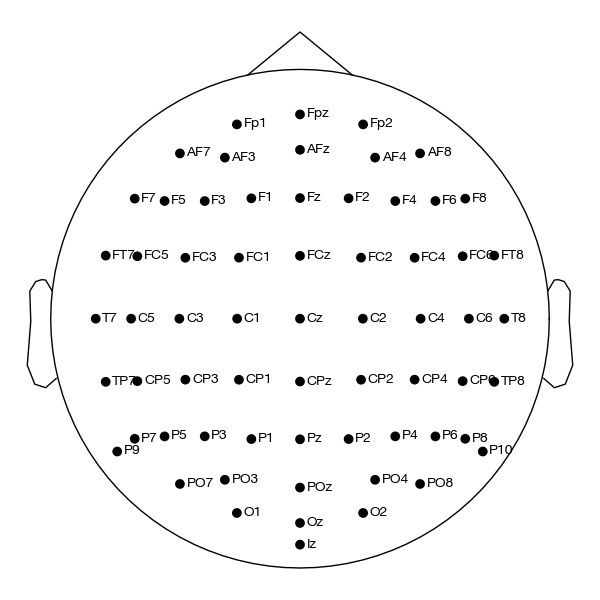

In [30]:
epochs.plot_sensors(ch_type='eeg', kind='topomap', show_names=True);

with frequency band: [8, 12], and settings: ['T1P', 'T1Pn']: 100%|██████████| 64/64 [05:58<00:00,  5.61s/it]


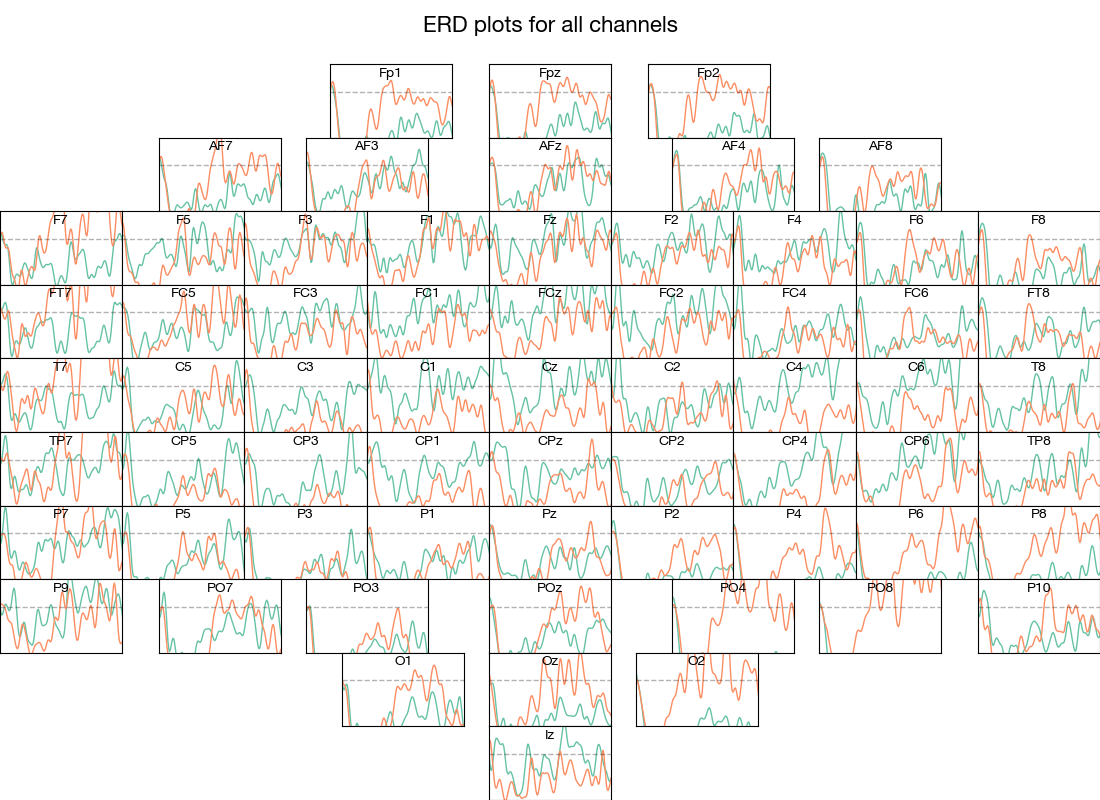

In [171]:
window = 1
settings = ['T1P', 'T1Pn']
overlap = 0.9
epochs = epochs_df['Epochs'][:1]
band = [8,12]
mne.set_log_level('WARNING')
# Define grid size based on your ch_grid_dict
n_cols = max(pos[0] for pos in ch_grid_dict.values()) + 1
n_rows = max(pos[1] for pos in ch_grid_dict.values()) + 1

fig = plt.figure(figsize=(11, 8))



for ch, (x, y) in tqdm(ch_grid_dict.items(), desc=f'with frequency band: {band}, and settings: {settings}'):
    
    psds = get_psds_for_channel(participants_data=epochs, overlap=overlap, channel=ch, band=band, window=window, settings=settings);
    # Normalize positions to [0, 1] figure coordinates
    top_margin = 0.08 
    ax_width = 1 / n_cols
    ax_height = (1 - top_margin) / n_rows

    left = x * ax_width
    bottom = 1 - top_margin - (y + 1) * ax_height
    
    ax = fig.add_axes([left, bottom, ax_width, ax_height])
    plot_ERD(psds, ax)
    ax.text(0.5, 0.95, ch, ha='center', va='top', transform=ax.transAxes, fontsize=10)
    # ax.set_xticks([])
    # ax.set_yticks([])

plt.suptitle("ERD plots for all channels", fontsize=16)
plt.show()